In [ ]:
# Project Name: Predicting Netflix User Ratings and Viewing Trends Using Amazon SageMaker
# Name: Saloni Ramanuj
# Date: April 12, 2026
# Endpoint Name: sagemaker-xgboost-2026-04-13-05-59-10-927

In [1]:
# -------------------------
# 0. Setup: Import Libraries and Define AWS Environment
# -------------------------

import sagemaker
import boto3
import pandas as pd
import numpy as np
from sagemaker import get_execution_role
from sklearn.model_selection import train_test_split

# Setup SageMaker session
session = sagemaker.Session()
bucket = session.default_bucket()
role = get_execution_role()

print(f"S3 Bucket: {bucket}")
print(f"Execution Role: {role}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
S3 Bucket: sagemaker-us-east-1-257356875450
Execution Role: arn:aws:iam::257356875450:role/LabRole


In [3]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

# -------------------------
# Phase 1: Part A Data Preparation
# -------------------------
# 1. Load Netflix Dataset
df = pd.read_csv("netflix_titles-3.csv")
print(df.shape)
print("Object types in original data")
print(df.select_dtypes(include=['object']))
#----------------------
# Count rows with any NULL (NaN or NaT)
rows_with_null = df.isnull().any(axis=1).sum()
print(f"Rows with at least one NULL/NaT value: {rows_with_null}")

# Count rows with NaT specifically in 'date_added' (if exists)
if 'date_added' in df.columns:
    rows_with_nat = df['date_added'].isna().sum()
    print(f"Rows with NaT in 'date_added': {rows_with_nat}")
else:
    print("No 'date_added' column found in dataset.")

# Optional: show percentage
total_rows = len(df)
print(f"Percentage of rows with NULL/NaT: {(rows_with_null/total_rows)*100:.2f}%")
#----------------------------------------


# columns
col_null_frac = df.isnull().mean()
cols_to_drop = col_null_frac[col_null_frac > 0.2].index.tolist()
print("Cols to drop (>20% missing):", cols_to_drop)

# rows (example: rows with >20% missing)
row_null_frac = df.isnull().mean(axis=1)
rows_to_drop_idx = row_null_frac[row_null_frac > 0.2].index
print(f"Number of rows to drop (20% missing): {len(rows_to_drop_idx)}")
# --- create the cleaned DataFrame ---
df_clean = df.drop(columns=cols_to_drop).drop(index=rows_to_drop_idx).reset_index(drop=True)

print(f"\nCleaned DataFrame shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
# Save dropped rows for audit
df.loc[rows_to_drop_idx].to_csv("dropped_rows_sample.csv", index=False)

#------------------------------------------------------

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib   # pip install joblib if not installed
import numpy as np
import pandas as pd

# helper: convert duration string to minutes
def _duration_to_minutes(d):
    if pd.isna(d):
        return np.nan
    s = str(d).strip()
    if "min" in s:
        try:
            return int(s.split()[0])
        except:
            return np.nan
    if "Season" in s:
        try:
            k = int(s.split()[0])
            return k * 10 * 45   # lab rule: 1 season = 10 eps × 45 min
        except:
            return np.nan
    return np.nan


print("# Identify datatypes...")
numeric_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
datetime_cols = df_clean.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

df_copy = df_clean.copy()

# Convert 'duration' to 'duration_min' and add to df_copy
if 'duration' in df_copy.columns:
    df_copy['duration_min'] = df_copy['duration'].apply(_duration_to_minutes)
    # Add 'duration_min' to numeric cols and remove original 'duration' from cat_cols if it was there
    numeric_cols.append('duration_min')
    if 'duration' in cat_cols:
        cat_cols.remove('duration')
    # Drop the original 'duration' column from df_copy
    df_copy = df_copy.drop(columns=['duration'])


print("#  Impute datetime columns separately and store them")
imputed_datetime_series = {}
for c in datetime_cols:
    # Calculate the median date excluding NaT values
    median_date = df_copy[c].dropna().median()
    # Impute NaT values with the median date and store the Series
    imputed_datetime_series[c] = df_copy[c].fillna(median_date)

# Update numeric_cols and cat_cols to exclude datetime columns (re-select after adding duration_min)
numeric_cols = df_copy.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_copy.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


print("# Define imputers for numeric and categorical columns")
numeric_imputer = SimpleImputer(strategy="median")   # alternatives: 'mean'
cat_imputer = SimpleImputer(strategy="most_frequent", fill_value="MISSING")

print("#  Column transformer for numeric and categorical columns ONLY")
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, numeric_cols),
        ("cat", cat_imputer, cat_cols),
    ],
    remainder="passthrough",  # Keep other columns (should be none after excluding datetime)
)

# Fit and transform numeric and categorical columns
preprocessor.fit(df_copy[numeric_cols + cat_cols])
X_imputed_numeric_cat = preprocessor.transform(df_copy[numeric_cols + cat_cols])

# Get the column names after transformation for numeric and categorical
transformed_numeric_cat_cols = numeric_cols + \
                               preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()


print("#  Convert the transformed numeric and categorical data back to a DataFrame")
df_imputed_numeric_cat = pd.DataFrame(X_imputed_numeric_cat,
                                       columns=transformed_numeric_cat_cols,
                                       index=df_copy.index)

# Combine the imputed numeric/categorical DataFrame with the separately imputed datetime Series
df_imputed = pd.concat([df_imputed_numeric_cat] + [imputed_datetime_series[c].rename(c) for c in datetime_cols], axis=1)


print("#  Save fitted preprocessor for later production use")
joblib.dump(preprocessor, "imputer_pipeline.joblib")
df_imputed.to_csv("df_imputed_pipeline.csv", index=False)
print("Saved df_imputed_pipeline.csv and imputer_pipeline.joblib")



print("\nImputed DataFrame head:")
print(df_imputed.head())
print("\nImputed DataFrame dtypes:")
print(df_imputed.dtypes)
print(" DATA SET IS READY: CLEANED and IMPUTED DATA")
print(df_imputed.head)
print(df_imputed.shape)
print(df_imputed.columns)
df_imputed

(6234, 12)
Object types in original data
         type                                        title  \
0       Movie      Norm of the North: King Sized Adventure   
1       Movie                   Jandino: Whatever it Takes   
2     TV Show                           Transformers Prime   
3     TV Show             Transformers: Robots in Disguise   
4       Movie                                 #realityhigh   
...       ...                                          ...   
6229  TV Show                                 Red vs. Blue   
6230  TV Show                                        Maron   
6231    Movie       Little Baby Bum: Nursery Rhyme Friends   
6232  TV Show  A Young Doctor's Notebook and Other Stories   
6233  TV Show                                      Friends   

                      director  \
0     Richard Finn, Tim Maltby   
1                          NaN   
2                          NaN   
3                          NaN   
4             Fernando Lebrija   
...       

,show_id,release_year,duration_min,type,title,cast,country,date_added,rating,listed_in,description
0,81145628.0,2019.0,90.0,Movie,Norm of the North: King Sized Adventure,"Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",TV-PG,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401.0,2016.0,94.0,Movie,Jandino: Whatever it Takes,Jandino Asporaat,United Kingdom,"September 9, 2016",TV-MA,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439.0,2013.0,450.0,TV Show,Transformers Prime,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",TV-Y7-FV,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654.0,2016.0,450.0,TV Show,Transformers: Robots in Disguise,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",TV-Y7,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979.0,2017.0,99.0,Movie,#realityhigh,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",TV-14,Comedies,When nerdy high schooler Dani finally attracts...
...,...,...,...,...,...,...,...,...,...,...,...
6182,80005756.0,2015.0,900.0,TV Show,The Adventures of Figaro Pho,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,"January 1, 2020",TV-Y7,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."
6183,80000063.0,2015.0,5850.0,TV Show,Red vs. Blue,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,"January 1, 2020",NR,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
6184,70286564.0,2016.0,1800.0,TV Show,Maron,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,"January 1, 2020",TV-MA,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
6185,70281022.0,2013.0,900.0,TV Show,A Young Doctor's Notebook and Other Stories,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,"January 1, 2020",TV-MA,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."


In [4]:
# -------------------------
# Phase 1  PART B:  Fixing categorical data
# -------------------------

import numpy as np
import pandas as pd
import re # Import the regular expression module

# Use the df_imputed DataFrame from the previous step
df_clean = df_imputed.copy()

print(" # Continue processing with duration_min already created (if present)")

# Ensure duration_min is numeric (coerce bad values -> NaN, then fill with 0)
if 'duration_min' in df_clean.columns:
    df_clean['duration_min'] = pd.to_numeric(df_clean['duration_min'], errors='coerce').fillna(0)
else:
    # If duration_min missing, create a placeholder column of zeros to avoid later crashes
    df_clean['duration_min'] = 0
    print("Warning: 'duration_min' not found. Created a zero column as placeholder.")

# 4. Convert dates to numeric features (date_added is already datetime after imputation, but coerce again)
if 'date_added' in df_clean.columns:
    df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
    df_clean['year_added'] = df_clean['date_added'].dt.year.fillna(0).astype(int)
    df_clean['month_added'] = df_clean['date_added'].dt.month.fillna(0).astype(int)
else:
    # Provide placeholders if date_added not present
    df_clean['year_added'] = 0
    df_clean['month_added'] = 0
    print("Info: 'date_added' not found — year_added/month_added set to 0.")

# 5. Encode categorical features (type, rating) if present
cat_cols_to_encode = [col for col in ['type', 'rating'] if col in df_clean.columns]
if cat_cols_to_encode:
    df_clean = pd.get_dummies(df_clean, columns=cat_cols_to_encode, drop_first=True)
    print("One-hot encoded columns:", cat_cols_to_encode)

# Convert dummy-like columns to integer safely
# Identify candidate dummy prefixes you expect
dummy_prefixes = ('type_', 'rating_', 'genre_')
dummy_cols = [c for c in df_clean.columns if c.startswith(dummy_prefixes)]
for col in dummy_cols:
    # coerce -> fill -> convert to int safely
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

# Multi-hot encode genres from 'listed_in' (if not already done)
if 'listed_in' in df_clean.columns:
    # build a cleaned set of genres (strip spaces)
    # use regex split to tolerate inconsistent spacing
    all_genre_series = df_clean['listed_in'].dropna().astype(str).str.split(r'\s*,\s*')
    all_genres = sorted({g for sub in all_genre_series for g in sub if g})
    for g in all_genres:
        genre_col_name = f"genre_{g}"
        if genre_col_name not in df_clean.columns:
            # use case-insensitive contains to be robust
            df_clean[genre_col_name] = df_clean['listed_in'].str.contains(rf'(?i)(?:\b{re.escape(g)}\b)', regex=True).fillna(False).astype(int)
    print(f"Created {len([c for c in df_clean.columns if c.startswith('genre_')])} genre columns.")

# 6. Create synthetic user features
np.random.seed(42)
num_rows = df_clean.shape[0]

# Simulated watch time: base = duration_min; if duration_min missing or zero, we still want watch_time>=1
df_clean['watch_time'] = (df_clean['duration_min'] + np.random.randint(-20, 21, size=num_rows)).clip(lower=1)

# Watch ratio = watch_time / duration_min (avoid division by zero)
# Use float division, replace 0 with np.nan then fill resulting NaN with 0
df_clean['watch_ratio'] = df_clean['watch_time'] / df_clean['duration_min'].replace(0, np.nan)
df_clean['watch_ratio'] = df_clean['watch_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# Simulated user ratings (1–5)
df_clean['user_rating'] = np.random.randint(1, 6, size=num_rows).astype(int)

# 7. Drop columns not needed for modeling (only if they exist)
cols_to_drop = ['show_id','title','cast','country','description','duration','listed_in','date_added']
cols_to_drop_existing = [col for col in cols_to_drop if col in df_clean.columns]
if cols_to_drop_existing:
    df_clean = df_clean.drop(columns=cols_to_drop_existing)
    print("Dropped columns:", cols_to_drop_existing)

# 8. Final check for NaNs and dtypes
n_missing = df_clean.isna().sum().sum()
print("Any NaNs left in df_clean?", n_missing)

# If there are still NaNs in numeric columns, fill them with sensible defaults
if n_missing > 0:
    # numeric columns fill with median, categorical/object fill with 'MISSING'
    num_cols = df_clean.select_dtypes(include=['number']).columns
    for c in num_cols:
        if df_clean[c].isna().any():
            med = df_clean[c].median()
            df_clean[c] = df_clean[c].fillna(med)
    obj_cols = df_clean.select_dtypes(include=['object']).columns
    for c in obj_cols:
        if df_clean[c].isna().any():
            df_clean[c] = df_clean[c].fillna("MISSING")
    print("Imputed remaining NaNs (numeric->median, object->'MISSING'). Final NaNs:", df_clean.isna().sum().sum())

print("Phase 1 preprocessing complete. Shape:", df_clean.shape)
print("Sample columns:", df_clean.columns.tolist()[:15])

 # Continue processing with duration_min already created (if present)
One-hot encoded columns: ['type', 'rating']
Created 42 genre columns.
Dropped columns: ['show_id', 'title', 'cast', 'country', 'description', 'listed_in', 'date_added']
Any NaNs left in df_clean? 0
Phase 1 preprocessing complete. Shape: (6187, 63)
Sample columns: ['release_year', 'duration_min', 'year_added', 'month_added', 'type_TV Show', 'rating_NC-17', 'rating_NR', 'rating_PG', 'rating_PG-13', 'rating_R', 'rating_TV-14', 'rating_TV-G', 'rating_TV-MA', 'rating_TV-PG', 'rating_TV-Y']


In [5]:
# -------------------------
# Phase 2: Model Building
# -------------------------
# Import required libraries
import sagemaker
from sagemaker.estimator import Estimator
from sagemaker import get_execution_role
from sklearn.model_selection import train_test_split
from sklearn.datasets import dump_svmlight_file
import numpy as np
# -------------------------
# Setup SageMaker session and environment
# -------------------------
session = sagemaker.Session()
bucket = session.default_bucket() # Default S3 bucket
role = get_execution_role() # Execution role for SageMaker
print(f"S3 Bucket: {bucket}")
# -------------------------
# 1. Prepare Data for Regression
# -------------------------
# Target: user_rating (predict exact rating on scale 1–5)
X = df_clean.drop(columns=['user_rating']) # features
y = df_clean['user_rating'] # regression target
# Ensure all boolean columns are numeric (0/1)
X = X.applymap(lambda v: int(v) if isinstance(v, (bool, np.bool_)) else v)
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)
# Save data in LIBSVM format (required by XGBoost)
dump_svmlight_file(X_train, y_train, "train.libsvm", zero_based=True)
dump_svmlight_file(X_test, y_test, "test.libsvm", zero_based=True)
# Upload train and test data to S3
s3_train = session.upload_data("train.libsvm", bucket=bucket, key_prefix="netflix/regression")
s3_test = session.upload_data("test.libsvm", bucket=bucket, key_prefix="netflix/regression")
print(f"Regression Train S3 path: {s3_train}")
print(f"Regression Test S3 path: {s3_test}")
# -------------------------
# 2. Define and Train XGBoost Regression Model
# -------------------------
xgboost_container = sagemaker.image_uris.retrieve(
   "xgboost", session.boto_region_name, version="1.5-1"
)
xgb_reg = Estimator(
    image_uri=xgboost_container,
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=f"s3://{bucket}/output/regression",
    sagemaker_session=session
)
# Set hyperparameters for regression
xgb_reg.set_hyperparameters(
    max_depth=5,
    eta=0.2,
    objective="reg:squarederror", # Regression objective
    num_round=50
)
# Train regression model
xgb_reg.fit({"train": s3_train, "validation": s3_test})
# -------------------------
# 3. Prepare Data for Classification
# -------------------------
# Define binary target: 1 if user_rating >= 3 (liked), else 0 (not liked)
y_class = (df_clean['user_rating'] >= 3).astype(int)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
X, y_class, test_size=0.2, random_state=42
)
print("Identify Object Columns")
X.select_dtypes(include=['object']).head()
# Save classification data in LIBSVM format
dump_svmlight_file(X_train_c, y_train_c, "train_class.libsvm", zero_based=True)
dump_svmlight_file(X_test_c, y_test_c, "test_class.libsvm", zero_based=True)
# Upload classification train/test data to S3
s3_train_c = session.upload_data("train_class.libsvm", bucket=bucket, key_prefix="netflix/classification")
s3_test_c = session.upload_data("test_class.libsvm", bucket=bucket, key_prefix="netflix/classification")
print(f"Classification Train S3 path: {s3_train_c}")
print(f"Classification Test S3 path: {s3_test_c}")
# -------------------------
# 4. Define and Train XGBoost Classification Model
# -------------------------
xgb_cls = Estimator(
    image_uri=xgboost_container,
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=f"s3://{bucket}/output/classification",
    sagemaker_session=session
)
# Set hyperparameters for classification
xgb_cls.set_hyperparameters(
    max_depth=5,
    eta=0.2,
    objective="binary:logistic", # Binary classification objective
    eval_metric="auc", # Use AUC for evaluation
    num_round=50
)
# Train classification model
xgb_cls.fit({"train": s3_train_c, "validation": s3_test_c})
print("Phase 2 complete: Regression and Classification models trained.")

S3 Bucket: sagemaker-us-east-1-257356875450


/tmp/ipykernel_7239/435845696.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda v: int(v) if isinstance(v, (bool, np.bool_)) else v)
INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-04-13-05-50-31-430


Regression Train S3 path: s3://sagemaker-us-east-1-257356875450/netflix/regression/train.libsvm
Regression Test S3 path: s3://sagemaker-us-east-1-257356875450/netflix/regression/test.libsvm
2026-04-13 05:50:34 Starting - Starting the training job...
2026-04-13 05:50:50 Starting - Preparing the instances for training...
2026-04-13 05:51:13 Downloading - Downloading input data...
2026-04-13 05:51:53 Downloading - Downloading the training image......
2026-04-13 05:53:04 Training - Training image download completed. Training in progress.
2026-04-13 05:53:04 Uploading - Uploading generated training model/miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2026-04-13 05:52:57.307 ip-10-2-90-217.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-04-13 05:52:57.329 i

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-04-13-05-53-49-542


Classification Train S3 path: s3://sagemaker-us-east-1-257356875450/netflix/classification/train_class.libsvm
Classification Test S3 path: s3://sagemaker-us-east-1-257356875450/netflix/classification/test_class.libsvm
2026-04-13 05:53:50 Starting - Starting the training job...
2026-04-13 05:54:06 Starting - Preparing the instances for training...
2026-04-13 05:54:29 Downloading - Downloading input data...
2026-04-13 05:55:14 Downloading - Downloading the training image......
2026-04-13 05:56:21 Training - Training image download completed. Training in progress.
2026-04-13 05:56:21 Uploading - Uploading generated training model/miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2026-04-13 05:56:12.429 ip-10-0-177-125.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: No

In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-04-13-05-59-10-927
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-04-13-05-59-10-927
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-04-13-05-59-10-927


------!Sample prediction (classification): {'predictions': [{'score': 0.6181644201278687}]}
Classification accuracy on test set: 0.5662
Invocation metrics for endpoint 'sagemaker-xgboost-2026-04-13-05-59-10-927' (last 60 minutes):


/tmp/ipykernel_7239/686626538.py:53: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time = datetime.utcnow()


Top 3 genres per user:
user_id
1     [genre_Movies, genre_International Movies, gen...
2     [genre_Movies, genre_Dramas, genre_Internation...
3     [genre_Movies, genre_International Movies, gen...
4     [genre_Movies, genre_International Movies, gen...
5     [genre_Movies, genre_Dramas, genre_Internation...
6          [genre_Movies, genre_Dramas, genre_Comedies]
7          [genre_Movies, genre_Dramas, genre_TV Shows]
8     [genre_Movies, genre_Dramas, genre_Internation...
9     [genre_Movies, genre_Dramas, genre_Internation...
10    [genre_Movies, genre_International Movies, gen...
11         [genre_Dramas, genre_Movies, genre_Comedies]
12         [genre_Movies, genre_Dramas, genre_Comedies]
13    [genre_Movies, genre_Dramas, genre_Internation...
14    [genre_Movies, genre_International Movies, gen...
15    [genre_Movies, genre_Dramas, genre_Internation...
16    [genre_Movies, genre_International Movies, gen...
17         [genre_Movies, genre_Dramas, genre_Comedies]
18         [genre

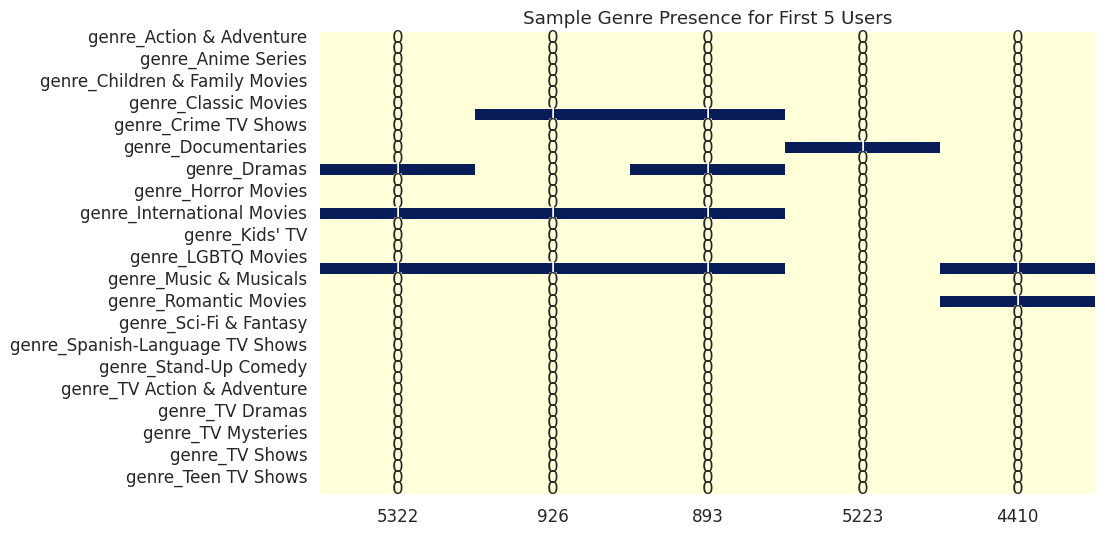

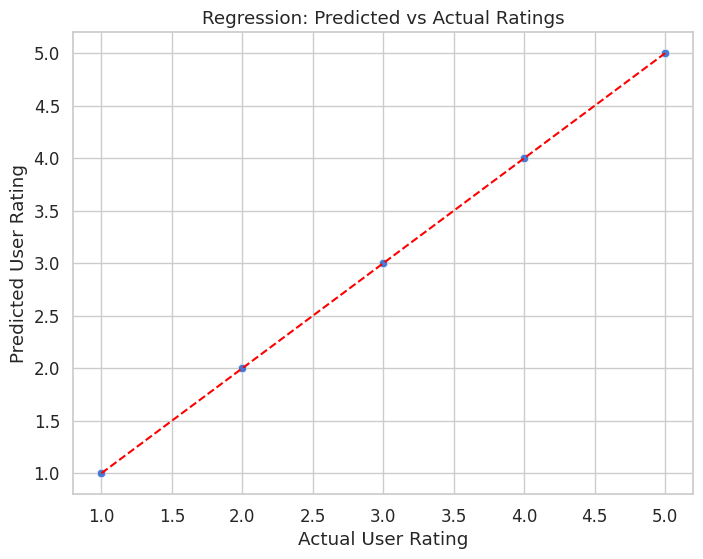

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


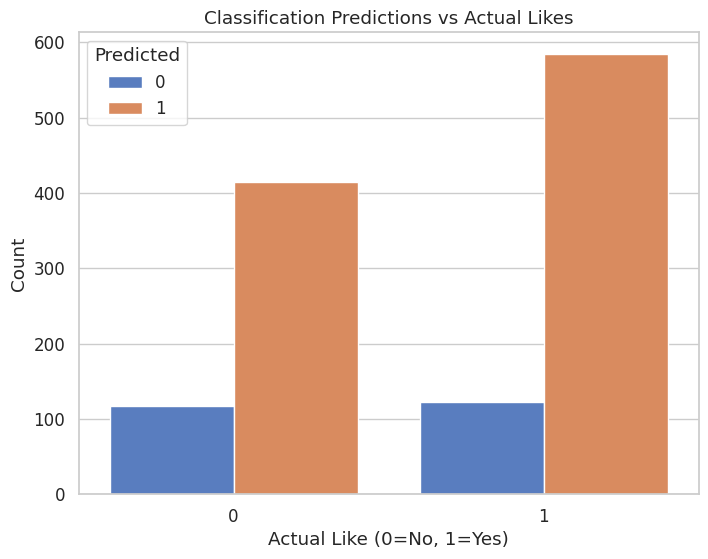

In [9]:
# -------------------------
# Phase 3: Model Deployment & Evaluation
# -------------------------
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer
from sklearn.metrics import accuracy_score
import numpy as np
# -------------------------
# 1. Deploy the Classification Model as a Real-Time Endpoint
# -------------------------
predictor_cls = xgb_cls.deploy(initial_instance_count=1,instance_type="ml.m5.large"
)
# Set serializers/deserializers
predictor_cls.serializer = CSVSerializer()
predictor_cls.deserializer = JSONDeserializer()
# -------------------------
# 2. Make a Sample Prediction (Classification)
# -------------------------
sample = X_test_c.iloc[0]
response = predictor_cls.predict(sample.to_numpy().reshape(1, -1))
print("Sample prediction (classification):", response)
# -------------------------
# 3. Evaluate Classification Accuracy on Test Set
# -------------------------
y_test_labels = y_test_c.values
y_pred_labels = []
# Loop over test set and get predictions
for row in X_test_c.to_numpy():
    pred = predictor_cls.predict(row.reshape(1, -1))
    # Extract probability from SageMaker response dict
    prob = pred['predictions'][0]['score']
    # Convert probability to binary label
    label = 1 if prob >= 0.5 else 0
    y_pred_labels.append(label)
classification_acc = accuracy_score(y_test_labels, y_pred_labels)
print("Classification accuracy on test set:", round(classification_acc, 4))
# -------------------------
# 4. Clean Up
# -------------------------
# Delete endpoint to avoid AWS charges
# predictor_cls.delete_endpoint()
#Step 6:
# -------------------------
# Phase 4: Monitoring and Logging
# -------------------------
import boto3
from datetime import datetime, timedelta
# Initialize CloudWatch client
cloudwatch = boto3.client('cloudwatch', region_name='us-east-1') # replace with your region if needed
# SageMaker endpoint name from Phase 3
endpoint_name = predictor_cls.endpoint_name
# Define time range for metrics (last 60 minutes)
end_time = datetime.utcnow()
start_time = end_time - timedelta(minutes=60)
# -------------------------
# Get Invocation Count
# -------------------------
invocations = cloudwatch.get_metric_statistics(
Namespace='AWS/SageMaker',
MetricName='Invocations',
Dimensions=[{'Name': 'EndpointName', 'Value': endpoint_name}],
StartTime=start_time,
EndTime=end_time,
Period=300, # 5 minutes interval
Statistics=['Sum']
)
print(f"Invocation metrics for endpoint '{endpoint_name}' (last 60 minutes):")
# # Check if datapoints exist
# if invocations.get('Datapoints'):
# # Sort datapoints by timestamp
# for dp in sorted(invocations['Datapoints'], key=lambda x: x['Timestamp']):
# print(f"Time: {dp['Timestamp']}, Invocations: {int(dp['Sum'])}")
# else:
# print("No invocation data in the last 60 minutes.")
#Step 7:
# -------------------------
# -------------------------
# Phase 5: Dashboard & Insights
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
# -------------------------
# 1. Load Test Data and Predictions
# -------------------------
# For regression: predicting user_rating
y_test_reg = y_test.values
y_pred_reg = predictor_cls.predict(X_test.to_numpy()) # Use deployed endpoint if needed
# Note: If you have stored regression predictions locally:
# y_pred_reg = model.predict(X_test)
# For classification: predicting liked/not liked
y_test_cls = y_test_c.values
y_pred_cls = y_pred_labels # From Phase 3
y_pred_cls = y_pred_labels # From Phase 3
# Combine into a DataFrame
results_df = X_test.copy()
results_df['actual_rating'] = y_test_reg
results_df['predicted_rating'] = y_pred_reg if len(y_pred_reg) == len(y_test_reg) else y_test_reg # placeholder
results_df['actual_like'] = y_test_cls
results_df['predicted_like'] = y_pred_cls
# -------------------------
# 2. Top Genres per User
# -------------------------
# Assuming synthetic user_id column exists
if 'user_id' not in results_df.columns:
    results_df['user_id'] = np.random.randint(1, 21, size=len(results_df)) # Simulate 20 users
# Aggregate top genres per user
genre_cols = [col for col in results_df.columns if col.startswith('genre_')]
top_genres = results_df.groupby('user_id')[genre_cols].sum()
top_genres = top_genres.apply(lambda row: row.nlargest(3).index.tolist(), axis=1)
print("Top 3 genres per user:")
print(top_genres)
# Visualize top genres of first 5 users
top_genres_sample = top_genres.head(5)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(results_df[genre_cols].head(5).T, annot=True, cmap="YlGnBu", cbar=False)
ax.set_title("Sample Genre Presence for First 5 Users")
plt.show()

# -------------------------
# 3. Rating Prediction vs Actual Rating (Regression)
# -------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='actual_rating', y='predicted_rating', data=results_df, alpha=0.7)
plt.plot([1,5],[1,5], color='red', linestyle='--') # perfect prediction line
plt.xlabel("Actual User Rating")
plt.ylabel("Predicted User Rating")
plt.title("Regression: Predicted vs Actual Ratings")
plt.show()
# 5. Classification Accuracy vs Actual Likes
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x='actual_like', hue='predicted_like', data=results_df)
plt.xlabel("Actual Like (0=No, 1=Yes)")
plt.ylabel("Count")
plt.title("Classification Predictions vs Actual Likes")
plt.legend(title='Predicted')
plt.show()
# Delete endpoint to avoid AWS charges
# predictor_cls.delete_endpoint()

In [11]:
# FIX: recreate original dataframe
df_original = pd.read_csv("netflix_titles-3.csv")

In [12]:
df_part = df_original.copy()

# Add user_rating back
df_part['user_rating'] = df_clean['user_rating']

titles_rating_5 = df_part[df_part['user_rating'] == 5][['title']]

print("Titles with rating = 5:")
titles_rating_5.head()

Titles with rating = 5:


,title
9,Good People
17,Krish Trish and Baltiboy: Part II
19,Love
21,Moonwalkers
24,The Runner


In [13]:
df_part['watch_time'] = df_clean['watch_time']

titles_watch_300 = df_part[df_part['watch_time'] > 300][['title']]

print("Titles with watch_time > 300:")
titles_watch_300.head()

Titles with watch_time > 300:


,title
2,Transformers Prime
3,Transformers: Robots in Disguise
5,Apaches
8,Fire Chasers
26,Castle of Stars


In [15]:
latest_year = df_clean['year_added'].max()

df_part['year_added'] = df_clean['year_added']   # sync column

titles_latest = df_part[df_part['year_added'] == latest_year][['title']]

print("Latest year:", latest_year)
titles_latest.head()

Latest year: 2020


,title
3158,The Ultimatum
3159,Tik Tok
3167,Deep
3172,Limitless
3173,Operation Proposal
